# Segundo parcial practico AXR, CONECTA 4
Janko Sanga Helen 

### Conecta 4, simplificado, Construye un agente que juegue una version de Conecta 4, . Explica como evalua jugadas, explora columnas y explota jugadas ganadoras 

# Como se juega Conecta 4

Conecta 4 es un juego de dos jugadores. Cada jugador coloca una ficha en una columna del tablero y la ficha cae hasta la casilla más baja libre de esa columna. Gana quien logre conectar 4 fichas seguidas del mismo símbolo: en horizontal, en vertical o en diagonal.

En esta version el tablero puede tener cualquier tamaño, pero la regla de victoria siempre es la misma: conectar 4 fichas.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from tqdm import tqdm
except ModuleNotFoundError:
    def tqdm(iterable, *args, **kwargs):
        return iterable

# tamaño del tablero
FILAS = 6
COLUMNAS = 7
GANAR_CON = 4


# 1. ENTORNO (Clonado de tu clase Board)
#
class Board():
    def __init__(self):
        self.state = np.zeros((FILAS, COLUMNAS))

    def valid_moves(self):
        # En Conecta 4 las acciones validas son las COLUMNAS que no esten llenas arriba
        return [c for c in range(COLUMNAS) if self.state[0, c] == 0]

    def update(self, symbol, col):
        #  cae a la fila vacia mas baja de la columna elegida
        for r in reversed(range(FILAS)):
            if self.state[r, col] == 0:
                self.state[r, col] = symbol
                return

    def ver_linea(self, array):
        for i in range(len(array) - GANAR_CON + 1):
            sub_arreglo = array[i:i + GANAR_CON]
            if sum(sub_arreglo) == GANAR_CON: return 1
            if sum(sub_arreglo) == -GANAR_CON: return -1
        return 0

    def is_game_over(self):
        # Comprobar Filas
        for r in range(FILAS):
            res = self.ver_linea(self.state[r, :])
            if res != 0: return res
        # Comprobar Columnas
        for c in range(COLUMNAS):
            res = self.ver_linea(self.state[:, c])
            if res != 0: return res
        # Comprobar Diagonales
        for d in range(-FILAS + 1, COLUMNAS):
            res = self.ver_linea(self.state.diagonal(d))
            if res != 0: return res
            res = self.ver_linea(np.fliplr(self.state).diagonal(d))
            if res != 0: return res
        # Empate
        if len(self.valid_moves()) == 0: return 0
        return None

    def reset(self):
        self.state = np.zeros((FILAS, COLUMNAS))








In [ ]:
class Agent():
    def __init__(self, alpha=0.5, c=2.0):
        self.value_function = {}  
        self.alpha = alpha       
        self.positions = []   # Historial de posiciones de la partida
        
        # Parametros de UCB
        self.c = c                  
        self.state_counts = {}      # N(s): visitas por estado
        self.t = 1                  # Pasos globales del agente

    def reset(self):
        self.positions = []

    def move(self, board):
        valid_columns = board.valid_moves()
        max_value = -1000
        best_col = valid_columns[0]
        
        # El agente evalua las columnas simulando mentalmente la gravedad
        for col in valid_columns:
            next_board = board.state.copy()
            for r in reversed(range(FILAS)):
                if next_board[r, col] == 0:
                    next_board[r, col] = self.symbol
                    break
            
        
            next_state = str(next_board.reshape(FILAS * COLUMNAS))
            
            Q = 0.5 if self.value_function.get(next_state) is None else self.value_function.get(next_state)
            N_s = self.state_counts.get(next_state, 0)
            
            #  UCB
            if N_s == 0:
                value = 1000  # Fuerza la exploracion si el estado es nuevo
            else:
                value = Q + self.c * np.sqrt(np.log(self.t) / N_s)
                
            if value >= max_value:
                max_value = value
                best_col = col
                
        # Guardar el estado elegido para actualizar los contadores UCB
        next_board = board.state.copy()
        for r in reversed(range(FILAS)):
            if next_board[r, best_col] == 0:
                next_board[r, best_col] = self.symbol
                break
        chosen_state = str(next_board.reshape(FILAS * COLUMNAS))
        self.state_counts[chosen_state] = self.state_counts.get(chosen_state, 0) + 1
        self.t += 1
        
        return best_col

    def update(self, board):
        self.positions.append(str(board.state.reshape(FILAS * COLUMNAS)))

    def reward(self, reward):
        # actualiacion en reversa
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0.5
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]

In [7]:
class Game():
    def __init__(self, player1, player2):
        self.player1 = player1
        self.player2 = player2
        self.board = Board()

    def selfplay_with_graphs(self, rounds=20000):
        recompensa_acumulada = 0
        promedios_rendimiento = []

        for i in tqdm(range(1, rounds + 1)):
            self.board.reset()
            self.player1.reset()
            self.player2.reset()
            
            if np.random.choice([True, False]):
                p1, p2 = self.player1, self.player2
            else:
                p1, p2 = self.player2, self.player1
            p1.symbol = 1
            p2.symbol = -1
            
            game_over = False
            while not game_over:
                col = p1.move(self.board)
                self.board.update(p1.symbol, col)
                p1.update(self.board)
                p2.update(self.board)
                if self.board.is_game_over() is not None: break
                    
                col = p2.move(self.board)
                self.board.update(p2.symbol, col)
                p1.update(self.board)
                p2.update(self.board)
                if self.board.is_game_over() is not None: break

            winner = self.board.is_game_over()
            if winner == 0:
                p1.reward(0.5); p2.reward(0.5)
            else:
                if winner == p1.symbol:
                    p1.reward(1); p2.reward(0)
                else:
                    p1.reward(0); p2.reward(1)
            
            if winner == 0: r_partida = 0.5
            elif winner == self.player1.symbol: r_partida = 1.0
            else: r_partida = 0.0
                
            recompensa_acumulada += r_partida
            promedios_rendimiento.append(recompensa_acumulada / i)
            
        return promedios_rendimiento

In [8]:
# EJECUCIÓN UCB
agent1 = Agent(alpha=0.5, c=2.0)
agent2 = Agent(alpha=0.5, c=2.0)
game = Game(agent1, agent2)
curva = game.selfplay_with_graphs(20000)

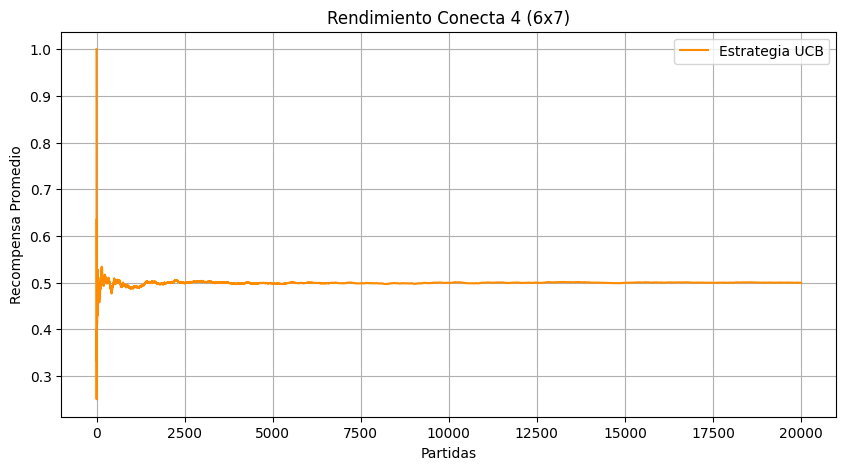

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(curva, color="darkorange", label="Estrategia UCB")
plt.grid(True)
plt.title(f"Rendimiento Conecta 4 ({FILAS}x{COLUMNAS})")
plt.xlabel("Partidas")
plt.ylabel("Recompensa Promedio")
plt.legend()
plt.show()

In [10]:
print(f"Total de estados en la funcion de valor: {len(agent1.value_function)}")


print("\nMuestra de la tabla (Funcion de Valor):")
for i, (estado, valor) in enumerate(agent1.value_function.items()):
    if i < 5:
        print(f"Estado {i+1}: {estado} -> Valor estimado: {valor:.4f}")

Total de estados en la funcion de valor: 253229

Muestra de la tabla (Funcion de Valor):
Estado 1: [ 0.  0.  0.  0. -1. -1. -1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0.
 -1. -1. -1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0. -1. -1. -1.  0.
  0.  0.  1.  1.  1.  1.] -> Valor estimado: 0.3750
Estado 2: [ 0.  0.  0.  0. -1. -1. -1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0.
 -1. -1. -1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0. -1. -1. -1.  0.
  0.  0.  0.  1.  1.  1.] -> Valor estimado: 0.5000
Estado 3: [ 0.  0.  0.  0.  0. -1. -1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0.
 -1. -1. -1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0. -1. -1. -1.  0.
  0.  0.  0.  1.  1.  1.] -> Valor estimado: 0.5312
Estado 4: [ 0.  0.  0.  0.  0. -1. -1.  0.  0.  0.  0.  0.  1.  1.  0.  0.  0.  0.
 -1. -1. -1.  0.  0.  0.  0.  1.  1.  1.  0.  0.  0.  0. -1. -1. -1.  0.
  0.  0.  0.  1.  1.  1.] -> Valor estimado: 0.5312
Estado 5: [ 0.  0.  0.  0.  0. -1. -1.  0.  0.  0.  0.  0.  1.  1.  0.  0.  0. 